In [7]:
#análise estatística
import numpy as np
import pandas as pd
from scipy.stats import (friedmanchisquare, wilcoxon)
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

#MCC
mcc_rf = np.array([0.76959638,0.75727179,0.76959638,0.79231045,0.78827875,0.80580935,0.76342156,0.78103164,0.76308624,0.71826047])
mcc_xgb = np.array([0.79062974,0.76233146,0.75320142,0.81810613,0.81810613,0.8190334,0.76794882,0.82442449,0.75215565,0.79492301])
mcc_svm = np.array([0.8081097,0.80149986,0.78381394,0.80538556,0.78865215,0.83377319,0.82693839,0.81339466,0.78372441,0.74891868])
'''
RF
Recall: [0.76811594 0.75362319 0.76811594 0.80434783 0.78985507 0.78985507 0.76086957 0.75912409 0.75912409 0.73913043]
MCC:    [0.76959638 0.75727179 0.76959638 0.79231045 0.78827875 0.80580935 0.76342156 0.78103164 0.76308624 0.71826047]
ACC:    [0.875 0.86764706 0.875 0.88970588 0.88602941 0.89338235 0.87132353 0.87867647 0.87132353 0.84926471]
ROC:    [0.94002812 0.91780229 0.91910015 0.96355181 0.9362427 0.94603072 0.94722898 0.94225466 0.93310621 0.95241185]
F1:     [0.86178862 0.85245902 0.86178862 0.88095238 0.87550201 0.88259109 0.85714286 0.86307054 0.85596708 0.83265306]


XGBoost
Recall: [0.84782609 0.82608696 0.83333333 0.87681159 0.87681159 0.86956522 0.84057971 0.83941606 0.83941606 0.82608696]
MCC:    [0.79062974 0.76233146 0.75320142 0.81810613 0.81810613 0.8190334 0.76794882 0.82442449 0.75215565 0.79492301]
ACC:    [0.89338235 0.87867647 0.875 0.88235294 0.90808824 0.875 0.90808824 0.90808824 0.90808824 0.89338235]
ROC:    [0.94094744 0.94770712 0.92142548 0.95944192 0.94332684 0.96263249 0.94067705 0.95139227 0.94695864 0.93424183]
F1:     [0.88973384 0.87356322 0.87121212 0.90636704 0.90636704 0.90566038 0.87878788 0.90196078 0.87121212 0.88715953]


SVM
Recall: [0.84057971 0.83333333 0.80434783 0.85507246 0.86231884 0.87681159 0.86956522 0.81751825 0.83941606 0.8115942 ]
MCC:    [0.8081097 0.80149986 0.78381394 0.80538556 0.78865215 0.83377319 0.82693839 0.81339466 0.78372441 0.74891868]
ACC:    [0.90073529 0.89705882 0.88602941 0.90073529 0.89338235 0.91544118 0.91176471 0.90073529 0.88970588 0.87132353]
ROC:    [0.95771144 0.93948735 0.93856803 0.96192948 0.9429483 0.95500757 0.95711659 0.93863206 0.95560962 0.94110967]
F1:     [0.8957529 0.89147287 0.87747036 0.8973384 0.89138577 0.91320755 0.90909091 0.89243028 0.88461538 0.86486486]
'''

#Teste global: Friedman


stat, p = friedmanchisquare(
    mcc_rf,
    mcc_xgb,
    mcc_svm
)
print("====== Teste Friedman para o MCC =========")
print(f'Estatística = {stat:.4f}')
print(f'p-valor = {p:.4f}')


====== Teste Friedman para o MCC =========
Estatística = 10.4000
p-valor = 0.0055


In [ ]:
#Existem diferenças estatisticamente significativas entre os modelos avaliados em termos de MCC.

In [6]:
f1_rf = np.array([0.86178862,0.85245902,0.86178862,0.88095238,0.87550201,0.88259109,0.85714286,0.86307054,0.85596708,0.83265306])
f1_xgb = np.array([0.88973384,0.87356322,0.87121212,0.90636704,0.90636704,0.90566038,0.87878788,0.90196078,0.87121212,0.88715953])
f1_svm = np.array([0.8957529,0.89147287,0.87747036,0.8973384,0.89138577,0.91320755,0.90909091,0.89243028,0.88461538,0.86486486])

stat, p = friedmanchisquare(
    f1_rf,
    f1_xgb,
    f1_svm
)
print("====== Teste Friedman para o F1 =========")
print(f'Estatística = {stat:.4f}')
print(f'p-valor = {p:.4f}')

roc_rf = np.array([0.94002812,0.91780229,0.91910015,0.96355181,0.9362427,0.95241185,0.94603072,0.94722898,0.94225466,0.93310621])
roc_xgb = np.array([0.94094744,0.94770712,0.92142548,0.95944192,0.94332684,0.96263249,0.94067705,0.95139227,0.94695864,0.93424183])
roc_svm = np.array([0.95771144,0.93948735,0.93856803,0.96192948,0.9429483,0.95500757,0.95711659,0.93863206,0.95560962,0.94110967])


stat, p = friedmanchisquare(
    f1_rf,
    f1_xgb,
    f1_svm
)
print("====== Teste Friedman para o ROC =========")
print(f'Estatística = {stat:.4f}')
print(f'p-valor = {p:.4f}')


====== Teste Friedman para o F1 =========
Estatística = 15.2000
p-valor = 0.0005
====== Teste Friedman para o ROC =========
Estatística = 15.2000
p-valor = 0.0005


In [9]:
# Existem diferenças estatisticamente significativas entre pelo menos dois dos modelos comparados em termos de MCC, F1-score e ROC-AUC.

# teste de Wilcoxon
#mcc
comparacoes = {
    "RF × XGBoost": wilcoxon(mcc_rf, mcc_xgb).pvalue,
    "RF × SVM": wilcoxon(mcc_rf, mcc_svm).pvalue,
    "XGBoost × SVM": wilcoxon(mcc_xgb, mcc_svm).pvalue
}

p_values = list(comparacoes.values())

_, p_corrigidos, _, _ = multipletests(
    p_values,
    method="holm"
)

print("\n teste de Wilcoxon para MCC \n")
for nome, p in zip(comparacoes.keys(), p_corrigidos):
    print(f"{nome}: p = {p:.4f}")

#f1
comparacoes = {
    "RF × XGBoost": wilcoxon(f1_rf, f1_xgb).pvalue,
    "RF × SVM": wilcoxon(f1_rf, f1_svm).pvalue,
    "XGBoost × SVM": wilcoxon(f1_xgb, f1_svm).pvalue
}

p_values = list(comparacoes.values())

_, p_corrigidos, _, _ = multipletests(
    p_values,
    method="holm"
)

print("\n teste de Wilcoxon para F1 \n")
for nome, p in zip(comparacoes.keys(), p_corrigidos):
    print(f"{nome}: p = {p:.4f}")

#ROC
comparacoes = {
    "RF × XGBoost": wilcoxon(roc_rf, roc_xgb).pvalue,
    "RF × SVM": wilcoxon(roc_rf, roc_svm).pvalue,
    "XGBoost × SVM": wilcoxon(roc_xgb, roc_svm).pvalue
}

p_values = list(comparacoes.values())

_, p_corrigidos, _, _ = multipletests(
    p_values,
    method="holm"
)

print("\n teste de Wilcoxon para ROC \n")
for nome, p in zip(comparacoes.keys(), p_corrigidos):
    print(f"{nome}: p = {p:.4f}")



 teste de Wilcoxon para MCC 

RF × XGBoost: p = 0.0977
RF × SVM: p = 0.0059
XGBoost × SVM: p = 0.3223

 teste de Wilcoxon para F1 

RF × XGBoost: p = 0.0059
RF × SVM: p = 0.0059
XGBoost × SVM: p = 0.8457

 teste de Wilcoxon para ROC 

RF × XGBoost: p = 0.2109
RF × SVM: p = 0.0820
XGBoost × SVM: p = 0.3223


In [12]:

# intervalo de confiança
from scipy import stats

def calcular_ic(valores):
    media = np.mean(valores)
    dp = np.std(valores, ddof=1)
    erro = stats.sem(valores)

    ic = stats.t.interval(
        0.95,
        len(valores) - 1,
        loc=media,
        scale=erro
    )

    return media, dp, ic

media, dp, ic = calcular_ic(mcc_rf)
print("\n =======Intervalo de confiança MCC RF ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')


media, dp, ic = calcular_ic(mcc_xgb)
print("\n =======Intervalo de confiança MCC XGBoost ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')


media, dp, ic = calcular_ic(mcc_svm)
print("\n =======Intervalo de confiança MCC SVM ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')


media, dp, ic = calcular_ic(f1_rf)
print("\n =======Intervalo de confiança F1 RF ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')


media, dp, ic = calcular_ic(f1_xgb)
print("\n =======Intervalo de confiança F1 XGB ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')


media, dp, ic = calcular_ic(f1_svm)
print("\n =======Intervalo de confiança F1 SVM ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')

media, dp, ic = calcular_ic(roc_rf)
print("\n =======Intervalo de confiança ROC RF ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')

media, dp, ic = calcular_ic(roc_xgb)
print("\n =======Intervalo de confiança ROC XGB ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')

media, dp, ic = calcular_ic(roc_svm)
print("\n =======Intervalo de confiança ROC SVM ==========\n")
print(f'{media:.4f} ± {dp:.4f}')
print(f'IC95%: [{ic[0]:.4f}, {ic[1]:.4f}]')



 =======Intervalo de confiança MCC RF ==========

0.7709 ± 0.0239
IC95%: [0.7537, 0.7880]

 =======Intervalo de confiança MCC XGBoost ==========

0.7901 ± 0.0292
IC95%: [0.7692, 0.8110]

 =======Intervalo de confiança MCC SVM ==========

0.7994 ± 0.0245
IC95%: [0.7819, 0.8170]

 =======Intervalo de confiança F1 RF ==========

0.8624 ± 0.0148
IC95%: [0.8518, 0.8730]

 =======Intervalo de confiança F1 XGB ==========

0.8892 ± 0.0150
IC95%: [0.8785, 0.8999]

 =======Intervalo de confiança F1 SVM ==========

0.8918 ± 0.0141
IC95%: [0.8817, 0.9018]

 =======Intervalo de confiança ROC RF ==========

0.9398 ± 0.0141
IC95%: [0.9297, 0.9499]

 =======Intervalo de confiança ROC XGB ==========

0.9449 ± 0.0119
IC95%: [0.9363, 0.9534]

 =======Intervalo de confiança ROC SVM ==========

0.9488 ± 0.0094
IC95%: [0.9421, 0.9555]


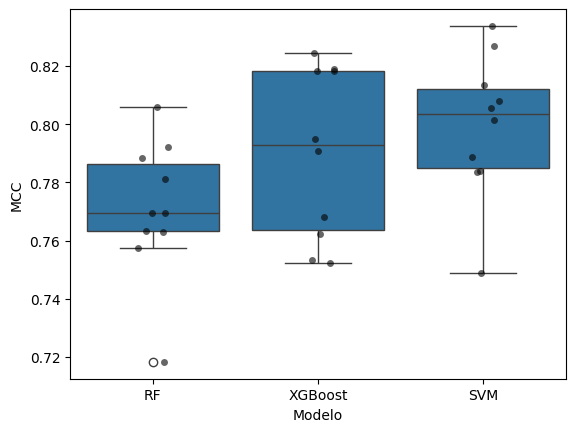

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'RF': mcc_rf,
    'XGBoost': mcc_xgb,
    'SVM': mcc_svm
})

df = df.melt(
    var_name='Modelo',
    value_name='MCC'
)

sns.boxplot(data=df, x='Modelo', y='MCC')
sns.stripplot(
    data=df,
    x='Modelo',
    y='MCC',
    color='black',
    alpha=0.6
)

plt.ylabel('MCC')
plt.show()

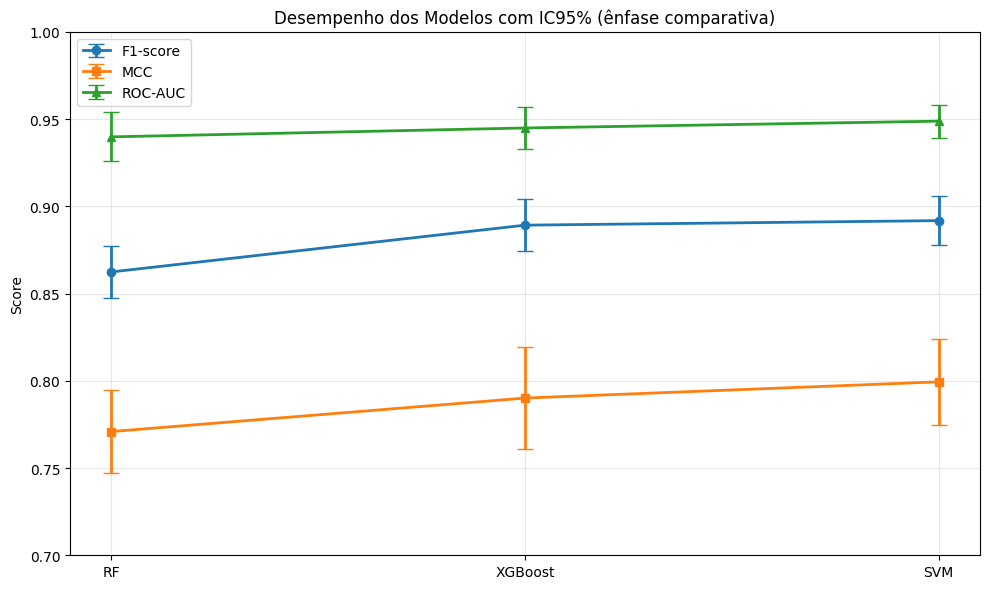

In [14]:


# =========================
# DADOS (IC95%)
# =========================

models = ["RF", "XGBoost", "SVM"]

mcc_mean = [0.7709, 0.7901, 0.7994]
mcc_err = [0.0239, 0.0292, 0.0245]

f1_mean = [0.8624, 0.8892, 0.8918]
f1_err = [0.0148, 0.0150, 0.0141]

roc_mean = [0.9398, 0.9449, 0.9488]
roc_err = [0.0141, 0.0119, 0.0094]


# =========================
# PLOT
# =========================

x = range(len(models))

plt.figure(figsize=(10, 6))

# F1 (métrica mais importante no seu caso)
plt.errorbar(models, f1_mean, yerr=f1_err, fmt='o-', capsize=6, label="F1-score", linewidth=2)

# MCC
plt.errorbar(models, mcc_mean, yerr=mcc_err, fmt='s-', capsize=6, label="MCC", linewidth=2)

# ROC
plt.errorbar(models, roc_mean, yerr=roc_err, fmt='^-', capsize=6, label="ROC-AUC", linewidth=2)

plt.title("Desempenho dos Modelos com IC95% (ênfase comparativa)")
plt.ylabel("Score")
plt.ylim(0.70, 1.00)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

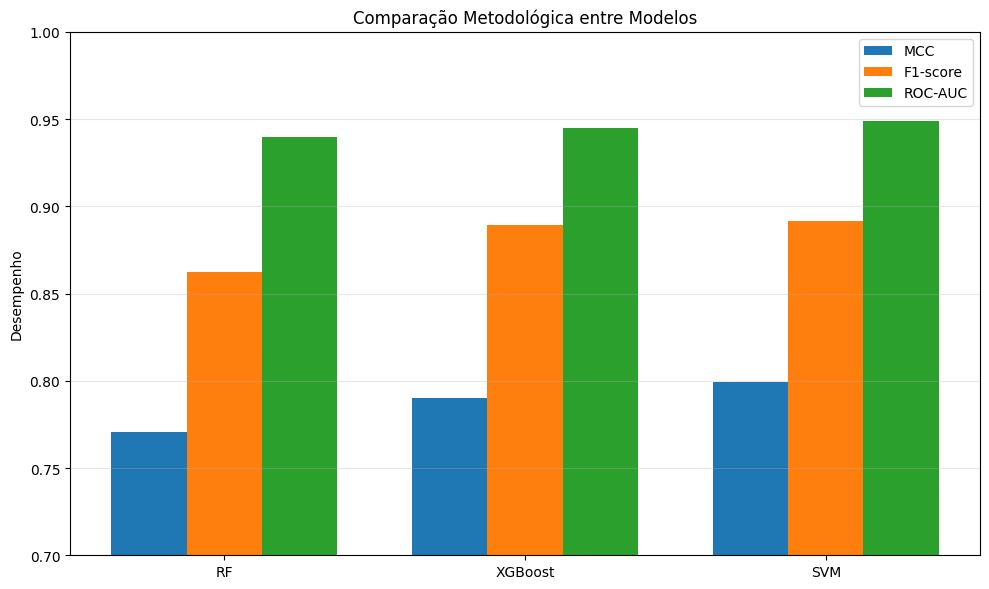

In [16]:


# =========================
# DADOS
# =========================

models = ["RF", "XGBoost", "SVM"]

data = {
    "MCC": [0.7709, 0.7901, 0.7994],
    "F1": [0.8624, 0.8892, 0.8918],
    "ROC-AUC": [0.9398, 0.9449, 0.9488]
}

# =========================
# CONFIGURAÇÃO DO GRÁFICO
# =========================

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, data["MCC"], width, label="MCC")
plt.bar(x, data["F1"], width, label="F1-score")
plt.bar(x + width, data["ROC-AUC"], width, label="ROC-AUC")

plt.xticks(x, models)
plt.ylabel("Desempenho")
plt.title("Comparação Metodológica entre Modelos")
plt.ylim(0.7, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Friedman statistic: 10.400000000000006
p-value: 0.005516564420760757

Average ranks:
SVM        1.4
XGBoost    1.8
RF         2.8
dtype: float64

Nemenyi p-values matrix:
          0         1         2
0  1.000000  0.065260  0.004965
1  0.065260  1.000000  0.643827
2  0.004965  0.643827  1.000000

Critical Difference (CD): 1.0478214542564015


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


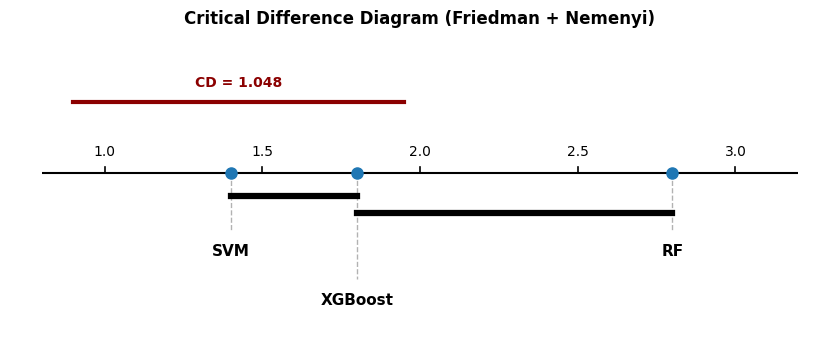

In [22]:
import scikit_posthocs as sp


# =========================================================
# 2. DATAFRAME (formato correto para Friedman/CD)
# =========================================================

df = pd.DataFrame({
    "RF": mcc_rf,
    "XGBoost": mcc_xgb,
    "SVM": mcc_svm
})

# =========================================================
# 3. FRIEDMAN TEST
# =========================================================

stat, p = friedmanchisquare(df["RF"], df["XGBoost"], df["SVM"])

print("Friedman statistic:", stat)
print("p-value:", p)

# =========================================================
# 4. RANKINGS POR FOLD
# =========================================================

ranks = df.rank(axis=1, ascending=False)
avg_ranks = ranks.mean().sort_values()

print("\nAverage ranks:")
print(avg_ranks)

# =========================================================
# 5. NEMENYI POST-HOC
# =========================================================

nemenyi = sp.posthoc_nemenyi_friedman(df.values)

print("\nNemenyi p-values matrix:")
print(nemenyi)

# =========================================================
# 6. CRITICAL DIFFERENCE (CD)
# =========================================================

def critical_difference(k, n, alpha=0.05):
    q_alpha = 2.343  # tabela Nemenyi (k=3, alpha=0.05)
    return q_alpha * np.sqrt(k * (k + 1) / (6 * n))

k = df.shape[1]
n = df.shape[0]

cd = critical_difference(k, n)

print("\nCritical Difference (CD):", cd)

def plot_cd(avg_ranks, cd):
    import matplotlib.pyplot as plt
    import numpy as np

    # 1. Configuração da figura (padrão de publicação)
    fig, ax = plt.subplots(figsize=(8.5, 3.5))
    sorted_models = avg_ranks.sort_values()
    
    # 2. Desenhar a régua de classificação (eixo principal) no topo
    y_axis = 1.0
    ax.hlines(y_axis, 0.8, 3.2, color="black", linewidth=1.5)
    
    # Adicionar os marcadores de escala (ticks) na régua de 0.5 em 0.5
    ticks = np.arange(1.0, 3.1, 0.5)
    for tick in ticks:
        ax.plot([tick, tick], [y_axis, y_axis + 0.02], color="black", linewidth=1.2)
        ax.text(tick, y_axis + 0.05, f"{tick:.1f}", ha="center", va="bottom", fontsize=10)

    # 3. Mapeamento manual de alturas para evitar colisões de texto
    # SVM (1.4) e XGBoost (1.8) são escalonados verticalmente
    label_y_positions = {
        "SVM": y_axis - 0.25,
        "XGBoost": y_axis - 0.42,  # Rebaixado para não colidir com o SVM
        "RF": y_axis - 0.25
    }
    
    # 4. Plotar os pontos dos modelos e suas linhas guias
    for model, rank in sorted_models.items():
        # Ponto marcador na régua
        ax.plot(rank, y_axis, 'o', color="#1f77b4", markersize=8, zorder=5)
        
        # Linha vertical tracejada conectando o ponto ao rótulo textual
        y_label = label_y_positions[model]
        ax.plot([rank, rank], [y_axis, y_label + 0.05], color="gray", linestyle="--", linewidth=1, alpha=0.6)
        
        # Nome do modelo destacado
        ax.text(rank, y_label, model, ha='center', va='top', fontsize=11, fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='none', pad=2))

    # 5. Desenhar as Barras de Significância Estrita (Cliques Reais do Teste de Nemenyi)
    # Grupo 1: SVM (1.4) até XGBoost (1.8) -> p = 0.6438 (Sem diferença significativa)
    ax.plot([1.4, 1.8], [y_axis - 0.08, y_axis - 0.08], color="black", linewidth=4.5)
    
    # Grupo 2: XGBoost (1.8) até RF (2.8) -> p = 0.0652 (Sem diferença significativa a alfa=0.05)
    ax.plot([1.8, 2.8], [y_axis - 0.14, y_axis - 0.14], color="black", linewidth=4.5)

    # 6. Indicador flutuante do tamanho do intervalo crítico (CD) no topo esquerdo
    cd_start = 0.9
    ax.plot([cd_start, cd_start + cd], [y_axis + 0.25, y_axis + 0.25], color="darkred", linewidth=3)
    ax.text(cd_start + cd/2, y_axis + 0.29, f"CD = {cd:.3f}", ha="center", va="bottom", color="darkred", fontsize=10, fontweight='bold')

    # 7. Ajustes finos de margens e remoção de bordas desnecessárias
    ax.set_xlim(0.7, 3.3)
    ax.set_ylim(y_axis - 0.55, y_axis + 0.4)
    ax.axis('off') # Oculta o box padrão do matplotlib que deixa o gráfico feio
    
    plt.title("Critical Difference Diagram (Friedman + Nemenyi)\n", fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    
    # Salva em alta resolução para o LaTeX/Word do artigo
    plt.savefig("critical_difference_final.eps", bbox_inches="tight", format="eps")
    plt.show()

plot_cd(avg_ranks, cd)